Imports

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

Import Data and Fill NaN Values

In [ ]:
DATA_GLOB = "data/Refit/*.csv"  

DATA_GLOB = DATA_GLOB.replace("*.csv", "*[!hourly_Temp_data].csv") 

print("Looking for files in:", DATA_GLOB)

# This function loads the hourly energy consumption data from a CSV file, processes it to ensure it has a DateTime index, and resamples it to ensure it has hourly frequency.
# The function's parameter is :
# - path: The path to the CSV file containing the hourly energy consumption data.
def load_household_hourly(path):
    df = pd.read_csv(path)
    df.rename(columns={'Time': 'Date', 'Aggregate': 'Volume'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.set_index('Date')

    df = df.resample('1h').mean()
    df = df.reset_index()    

    return df

# This function takes the hourly data and creates a daily matrix where each row corresponds to a day and each column corresponds to an hour of the day.
# This function's parameter is :
# - df_hourly: A DataFrame containing hourly energy consumption data with a 'Date' column and a 'Volume' column.
def make_daily_matrix(df_hourly):
    df = df_hourly.copy()
    df['Day'] = df['Date'].dt.date
    df['Hour'] = df['Date'].dt.hour
    df['Weekday'] = df['Date'].dt.weekday
    df['Month'] = df['Date'].dt.month

    group_median = (
        df
        .groupby(['Month', 'Weekday', 'Hour'])['Volume']
        .median()
        )
    def fill_with_group_median(row):
        if pd.isna(row['Volume']):
            return group_median.loc[(row['Weekday'], row['Hour'])]
        else:
            return row['Volume']
        
    # Number of missing values in Volume before filling with group median
    missing_count = df['Volume'].isna().sum()
    print(f"Missing values before filling: {missing_count} out of {len(df)} ({missing_count/len(df)*100:.2f}%)")
    missing_groups = (df['Volume'].isna() != df['Volume'].isna().shift()).cumsum()
    longest_gap = df[df['Volume'].isna()].groupby(missing_groups).size().max()
    print(f"Longest gap of missing values : {longest_gap} entries, which is {longest_gap / len(df) * 100:.2f}% of total entries.")
    
    df['Volume'] = df.apply(fill_with_group_median, axis=1)

    # restrict to time window to 1 year of best data quality
    df = df[(df['Date'] >= '2014-04-01') & (df['Date'] < '2015-04-01')]

    daily_matrix = df.pivot_table(index='Day',
                                  columns='Hour',
                                  values='Volume')
    daily_matrix = daily_matrix.dropna()
    daily_matrix = daily_matrix.reindex(columns=range(24))
    return daily_matrix


Looking for files in: data/Refit/*[!hourly_Temp_data].csv


DBSCAN Clustering Function

In [ ]:
# This function applies DBSCAN to the daily profiles and computes metrics about the clustering results.
# This Function's parameters are :
# - daily_matrix: A DataFrame where each row corresponds to a day and each column corresponds to an hour of the day, containing the energy consumption values.
def dbscan_daily_profiles(daily_matrix):
    X = daily_matrix.values   
    
    daily_energy = X.sum(axis=1)
    avg_daily_energy = daily_energy.mean()

    eps = 0.10 * avg_daily_energy
    min_samples = 2

    db = DBSCAN(eps=eps,
                min_samples=min_samples,
                metric='euclidean')
    labels = db.fit_predict(X)

    n_days = len(labels)
    n_outliers = np.sum(labels == -1)
    frac_outliers = n_outliers / n_days

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    metrics = {
        "n_days": n_days,
        "n_clusters": n_clusters,
        "n_outliers": n_outliers,
        "frac_outliers": frac_outliers,
        "avg_daily_energy": avg_daily_energy,
        "eps_used": eps,
    }
    return labels, metrics


Main Loop to Process Each Household and Run DBSCAN

In [ ]:
house_metrics = []

for path in glob.glob(DATA_GLOB):

    hid = os.path.splitext(os.path.basename(path))[0]
    
    df_hourly = load_household_hourly(path)
    daily_matrix = make_daily_matrix(df_hourly)

    if len(daily_matrix) < 5:
        print(f"  Not enough full days for {hid}, skipping.")
        continue

    labels, metrics = dbscan_daily_profiles(daily_matrix)
    metrics["HouseholdID"] = hid
    print(f"  Found {metrics['n_clusters']} clusters, "
          f"{metrics['n_outliers']} outliers "
          f"out of {metrics['n_days']} days.")
    house_metrics.append(metrics)

house_features = pd.DataFrame(house_metrics).set_index("HouseholdID")
print(house_features)


  Found 5 clusters, 64 outliers out of 365 days.
  Found 5 clusters, 139 outliers out of 365 days.
  Found 2 clusters, 67 outliers out of 365 days.
  Found 6 clusters, 115 outliers out of 365 days.
  Found 9 clusters, 187 outliers out of 365 days.
  Found 4 clusters, 106 outliers out of 365 days.
  Found 2 clusters, 35 outliers out of 365 days.
  Found 4 clusters, 94 outliers out of 365 days.
  Found 6 clusters, 53 outliers out of 365 days.
  Found 5 clusters, 76 outliers out of 365 days.
  Found 4 clusters, 25 outliers out of 365 days.
  Found 11 clusters, 102 outliers out of 365 days.
  Found 14 clusters, 189 outliers out of 365 days.
  Found 4 clusters, 100 outliers out of 365 days.
  Found 2 clusters, 13 outliers out of 365 days.
  Found 7 clusters, 149 outliers out of 365 days.
  Found 6 clusters, 138 outliers out of 365 days.
  Found 5 clusters, 42 outliers out of 301 days.
  Found 2 clusters, 45 outliers out of 365 days.
  Found 5 clusters, 164 outliers out of 365 days.
        

Prepare Data for second clustering run

In [ ]:
# Features to cluster on
feat_cols = ["frac_outliers", "n_clusters", "avg_daily_energy"]

X_house = house_features[feat_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_house)


Using the Elbow Method to Determine Optimal Epsilon for DBSCAN

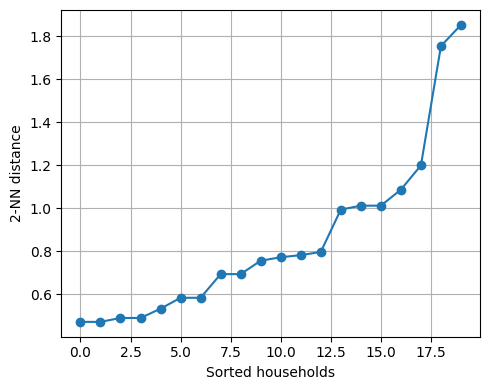

In [ ]:
k = 2
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

k_dist = np.sort(distances[:, k-1])

plt.figure(figsize=(5,4))
plt.plot(k_dist, marker='o')
plt.ylabel(f"{k}-NN distance")
plt.xlabel("Sorted households")
plt.grid(True)
plt.tight_layout()
plt.show()


DBSCAN Clustering second run

In [ ]:
eps_users = 1.0

from sklearn.cluster import DBSCAN

db_users = DBSCAN(eps=eps_users, min_samples=2)
user_labels = db_users.fit_predict(X_scaled)

house_features["cluster"] = user_labels
print(house_features.sort_values("cluster"))


               n_days  n_clusters  n_outliers  frac_outliers  \
HouseholdID                                                    
CLEAN_House12     365           6         138       0.378082   
CLEAN_House7      365           9         187       0.512329   
CLEAN_House1      365           4         106       0.290411   
CLEAN_House2      365          14         189       0.517808   
CLEAN_House17     365          11         102       0.279452   
CLEAN_House15     365           6          53       0.145205   
CLEAN_House8      365           5          64       0.175342   
CLEAN_House9      365           7         149       0.408219   
CLEAN_House16     365           4         100       0.273973   
CLEAN_House21     365           5          76       0.208219   
CLEAN_House5      365           4          94       0.257534   
CLEAN_House13     365           6         115       0.315068   
CLEAN_House10     365           5         139       0.380822   
CLEAN_House3      365           5       

Final metrics and visualization

         frac_outliers  n_clusters  avg_daily_energy
cluster                                             
-1            0.353881    8.333333       9866.816658
 0            0.308562    5.125000      15150.241111
 1            0.107731    2.833333       9468.318852

Cluster -1:
['CLEAN_House7', 'CLEAN_House1', 'CLEAN_House15', 'CLEAN_House17', 'CLEAN_House2', 'CLEAN_House12']

Cluster 0:
['CLEAN_House8', 'CLEAN_House10', 'CLEAN_House13', 'CLEAN_House5', 'CLEAN_House21', 'CLEAN_House16', 'CLEAN_House9', 'CLEAN_House3']

Cluster 1:
['CLEAN_House19', 'CLEAN_House18', 'CLEAN_House4', 'CLEAN_House6', 'CLEAN_House11', 'CLEAN_House20']


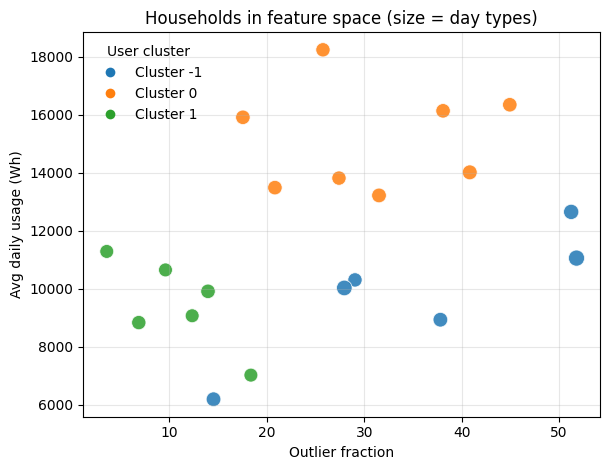

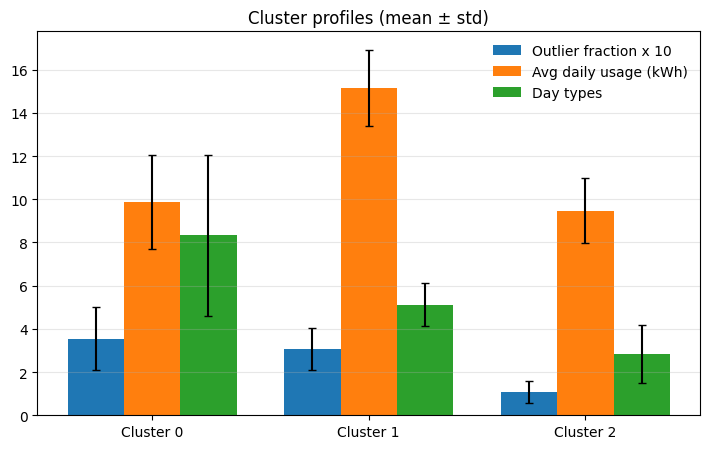

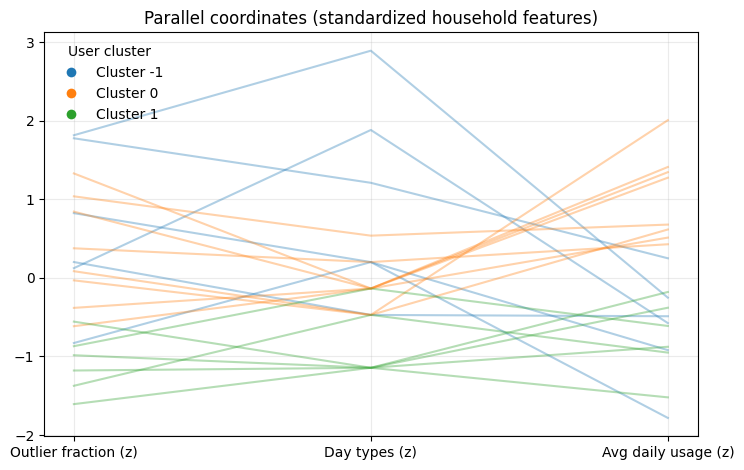

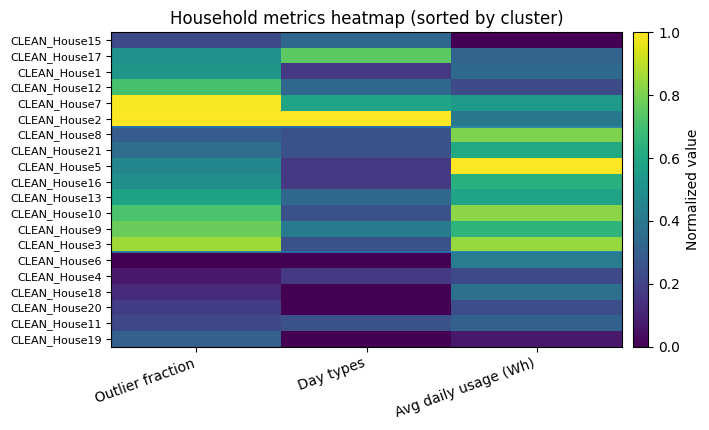

In [ ]:
# basic summary
print(house_features.groupby("cluster")[feat_cols].mean())

# which households in each cluster
for c, sub in house_features.groupby("cluster"):
    print(f"\nCluster {c}:")
    print(sub.index.tolist())

plot_df = house_features.copy()
# Rename for readability in plots
plot_df = plot_df.rename(columns={
    "frac_outliers": "Outlier fraction",
    "n_clusters": "Day types",
    "avg_daily_energy": "Avg daily usage (Wh)"
})

if plot_df.empty:
    raise ValueError("plot_df is empty after filtering; check clustering labels / include_noise flag.")

clusters_sorted = sorted(plot_df["cluster"].unique())

features = ["Outlier fraction", "Avg daily usage (Wh)", "Day types"]

cluster_stats = (
    plot_df
    .groupby("cluster")[features]
    .agg(["mean", "std"])
)

# Reformat for plotting
means = cluster_stats.xs("mean", axis=1, level=1).loc[clusters_sorted]
stds  = cluster_stats.xs("std",  axis=1, level=1).loc[clusters_sorted].fillna(0.0)

means['Avg daily usage (Wh)'] = means['Avg daily usage (Wh)'] / 1000  # scale up for visibility
means.rename(columns={'Avg daily usage (Wh)': 'Avg daily usage (kWh)'}, inplace=True)
means['Outlier fraction'] = means['Outlier fraction'] * 10  # convert
means.rename(columns={'Outlier fraction': 'Outlier fraction x 10'}, inplace=True)
stds['Avg daily usage (Wh)'] = stds['Avg daily usage (Wh)'] / 1000  # scale up for visibility
stds.rename(columns={'Avg daily usage (Wh)': 'Avg daily usage (kWh)'}, inplace=True)
stds['Outlier fraction'] = stds['Outlier fraction'] * 10
stds.rename(columns={'Outlier fraction': 'Outlier fraction x 10'}, inplace=True)

# rename features for plotting
features = ["Outlier fraction x 10", "Avg daily usage (kWh)", "Day types"]
x = np.arange(len(clusters_sorted))
width = 0.26

plt.figure(figsize=(7.2, 4.6))
ax = plt.gca()

for i, feat in enumerate(features):
    ax.bar(
        x + (i - 1) * width,
        means[feat].values,
        width=width,
        yerr=stds[feat].values,
        capsize=3,
        label=feat
    )

ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {c + 1}" for c in clusters_sorted])
ax.set_title("Cluster profiles (mean ± std)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()